# Recuperacion parcial de clave en KLEIN-64 reducido a 5 rondas

Este notebook implementa el ataque diferencial usual con pares elegidos de textos claros. No se generan pares sinteticos en estados intermedios.

Se utilizan las primeras cinco rondas de la caracteristica guardada en `find_characteristics/klein_64_6round_characteristic.json`:

$$\mathtt{1000000000000000}$$
$$\longrightarrow\mathtt{0000000030506030}$$
$$\longrightarrow\mathtt{60E0E00010300020}$$
$$\longrightarrow\mathtt{60500000E07000D0}$$
$$\longrightarrow\mathtt{00E0709020C08000}$$
$$\longrightarrow\mathtt{000070509000E070}.$$

La probabilidad de esta trayectoria de cinco rondas es

$$P=2^{-51},$$

que es estrictamente mayor que $2^{-64}$.

## 1. Probabilidad para el key recovery

Para atacar el whitening final de un KLEIN reducido a cinco rondas se necesita que el par llegue a la entrada de la quinta ronda con diferencia

$$\Delta U=\mathtt{00E0709020C08000}.$$

La probabilidad de las primeras cuatro rondas es

$$P_{\mathrm{prefijo}}=2^{-36}.$$

Por tanto, se espera aproximadamente un par util por cada $2^{36}$ pares elegidos. Aunque la trayectoria completa supera el umbral $2^{-64}$, su complejidad de datos sigue siendo demasiado alta para una ejecucion completa en un notebook.

## 2. Regla de conteo

La quinta ronda y el whitening final tienen la forma

$$U\xrightarrow{\oplus K_5}\xrightarrow{S}\xrightarrow{\operatorname{Rotate}}\xrightarrow{\operatorname{Mix}}\xrightarrow{\oplus K_6}C.$$

Se define

$$Z=\operatorname{InvRotate}(\operatorname{InvMix}(C)),$$

$$T=\operatorname{InvRotate}(\operatorname{InvMix}(K_6)).$$

Para un candidato $t$ se calcula

$$\widehat A_j(t)=S^{-1}(Z_j\oplus t).$$

El candidato recibe un punto si

$$\widehat A_j(t)\oplus\widehat A'_j(t)=\Delta U_j.$$

In [1]:
from pathlib import Path
import json
import math
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd


def add_repo_root_to_path():
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / "cryptosystems").is_dir() and (path / "find_characteristics").is_dir():
            if str(path) not in sys.path:
                sys.path.insert(0, str(path))
            return path
    raise RuntimeError("No se encontro la raiz del repositorio")


ROOT = add_repo_root_to_path()
from cryptosystems.klein import S_BOX_INV
from cryptosystems.reduced_klein import ReducedKLEIN

pd.set_option("display.max_columns", None)
print(f"Repo root: {ROOT}")

Repo root: C:\Users\juanc\github\Differential-Cryptanalysis-


## 3. Construccion de la caracteristica de cinco rondas

El JSON contiene seis rondas. Se toman sus primeros cinco registros y se recalculan la probabilidad y el peso.

In [2]:
path = ROOT / "find_characteristics" / "klein_64_6round_characteristic.json"
source_characteristic = json.loads(path.read_text(encoding="utf-8"))
round_records = source_characteristic["rounds"][:5]

DELTA_P = int(round_records[0]["input_difference"], 16)
DELTA_U = int(round_records[-1]["input_difference"], 16)
FINAL_DIFFERENCE = int(round_records[-1]["output_difference"], 16)
FULL_TRAIL_PROBABILITY = math.prod(float(item["probability"]) for item in round_records)
FULL_TRAIL_WEIGHT = -math.log2(FULL_TRAIL_PROBABILITY)
PREFIX_PROBABILITY = math.prod(float(item["probability"]) for item in round_records[:-1])
PREFIX_WEIGHT = -math.log2(PREFIX_PROBABILITY)

rounds_df = pd.DataFrame([
    {
        "ronda": item["round"],
        "entrada": item["input_difference"],
        "salida": item["output_difference"],
        "S-boxes activas": item["active_sboxes"],
        "probabilidad": item["probability"],
        "peso": item["weight"],
    }
    for item in round_records
])

print(f"Probabilidad de 5 rondas: {FULL_TRAIL_PROBABILITY:.12e} = 2^-{FULL_TRAIL_WEIGHT:.0f}")
print(f"Probabilidad hasta Delta U: {PREFIX_PROBABILITY:.12e} = 2^-{PREFIX_WEIGHT:.0f}")
print(f"Delta U: 0x{DELTA_U:016X}")
rounds_df

Probabilidad de 5 rondas: 4.440892098501e-16 = 2^-51
Probabilidad hasta Delta U: 1.455191522837e-11 = 2^-36
Delta U: 0x00E0709020C08000


,ronda,entrada,salida,S-boxes activas,probabilidad,peso
0,1,0x1000000000000000,0x0000000030506030,1,0.250000,2.0
1,2,0x0000000030506030,0x60E0E00010300020,4,0.000977,10.0
2,3,0x60E0E00010300020,0x60500000E07000D0,6,0.000122,13.0
3,4,0x60500000E07000D0,0x00E0709020C08000,5,0.000488,11.0
4,5,0x00E0709020C08000,0x000070509000E070,6,0.000031,15.0


## 4. Parametros y complejidad de datos

Se ejecutan $2^{16}$ pares reales. La cantidad esperada de pares que llegan a la entrada de la quinta ronda es

$$2^{16}\cdot2^{-36}=2^{-20}.$$

Lo normal es no observar ningun par correcto con esta muestra.

In [3]:
ROUNDS = 5
BLOCK_BITS = 64
KEY_BITS = 64
MASTER_KEY_HEX = "0011223344556677"
N_PAIRS = 1 << 16
SEED = 2026

cipher = ReducedKLEIN(rounds=ROUNDS, block_bits=BLOCK_BITS, key_bits=KEY_BITS)
round_keys = cipher.expand_round_keys_from_hex(MASTER_KEY_HEX)
true_final_whitening_key = round_keys[-1]


def split_nibbles(value: int) -> list[int]:
    return [(value >> shift) & 0xF for shift in range(BLOCK_BITS - 4, -1, -4)]


delta_u_nibbles = split_nibbles(DELTA_U)
ACTIVE_POSITIONS = [position for position, value in enumerate(delta_u_nibbles) if value != 0]

expected_right_pairs = N_PAIRS * PREFIX_PROBABILITY
pairs_for_one_expected = math.ceil(1 / PREFIX_PROBABILITY)
pairs_for_ten_expected = math.ceil(10 / PREFIX_PROBABILITY)

print(f"Posiciones activas: {ACTIVE_POSITIONS}")
print(f"Pares ejecutados: {N_PAIRS:,}")
print(f"Pares correctos esperados: {expected_right_pairs:.10f}")
print(f"Pares para 1 acierto esperado: {pairs_for_one_expected:,}")
print(f"Pares para 10 aciertos esperados: {pairs_for_ten_expected:,}")

Posiciones activas: [2, 4, 6, 8, 10, 12]
Pares ejecutados: 65,536
Pares correctos esperados: 0.0000009537
Pares para 1 acierto esperado: 68,719,476,736
Pares para 10 aciertos esperados: 687,194,767,360


## 5. Posiciones atacadas

La diferencia `00E0709020C08000` activa seis nibbles: 2, 4, 6, 8, 10 y 12.

In [4]:
pd.DataFrame([
    {
        "posicion": position,
        "Delta U": f"0x{value:X}",
        "activa": value != 0,
    }
    for position, value in enumerate(delta_u_nibbles)
])

,posicion,Delta U,activa
0,0,0x0,False
1,1,0x0,False
2,2,0xE,True
3,3,0x0,False
4,4,0x7,True
5,5,0x0,False
6,6,0x9,True
7,7,0x0,False
8,8,0x2,True
9,9,0x0,False


## 6. Generacion y cifrado de pares reales

Cada par se construye mediante $P'=P\oplus\Delta P$ y se cifra desde la primera ronda de KLEIN reducido.

In [5]:
def state_bytes_to_nibbles(state) -> list[int]:
    result = []
    for byte in state:
        result.extend([(int(byte) >> 4) & 0xF, int(byte) & 0xF])
    return result


def transformed_ciphertext_nibbles(ciphertext: int) -> list[int]:
    state = cipher._int_to_state(ciphertext)
    state = cipher._inv_mix(state)
    state = cipher._inv_rotate(state)
    return state_bytes_to_nibbles(state)


rng = random.Random(SEED)
transformed_pairs = []
sample_rows = []

for index in range(N_PAIRS):
    p = rng.randrange(0, 1 << BLOCK_BITS)
    p_prime = p ^ DELTA_P
    c = cipher.encrypt_block(p, round_keys)
    c_prime = cipher.encrypt_block(p_prime, round_keys)
    transformed_pairs.append((transformed_ciphertext_nibbles(c), transformed_ciphertext_nibbles(c_prime)))
    if index < 5:
        sample_rows.append({
            "P": f"0x{p:016X}",
            "P'": f"0x{p_prime:016X}",
            "C": f"0x{c:016X}",
            "C'": f"0x{c_prime:016X}",
        })

pd.DataFrame(sample_rows)

,P,P',C,C'
0,0xF3F49249DC28FF90,0xE3F49249DC28FF90,0x3865B35A158FDA41,0x30BFFE680F6ABE49
1,0xC4A334BFC6CD75E9,0xD4A334BFC6CD75E9,0x57E64DA7DFD090BE,0x84CCC2F81EA1B198
2,0x3D6C51E370EB9A0A,0x2D6C51E370EB9A0A,0xEBED7D28620ECC5B,0x3CC76F96D7A51E06
3,0x14AA4E719D3C7DEC,0x04AA4E719D3C7DEC,0xE073D40424981459,0xCB0E2497538A0238
4,0xD11745AD49889310,0xC11745AD49889310,0xF1D6E94BD57FAB4C,0x18F7A2FE47BC4249


## 7. Conteo de candidatos

Para cada posicion activa se prueban los 16 candidatos posibles del nibble de la clave transformada $T$.

In [6]:
def score_candidate(key_guess: int, position: int) -> int:
    target_delta = delta_u_nibbles[position]
    score = 0
    for z, z_prime in transformed_pairs:
        a_hat = S_BOX_INV[z[position] ^ key_guess]
        a_hat_prime = S_BOX_INV[z_prime[position] ^ key_guess]
        if (a_hat ^ a_hat_prime) == target_delta:
            score += 1
    return score


scores_by_position = {}
for position in ACTIVE_POSITIONS:
    rows = [
        {
            "candidate_int": key_guess,
            "candidato": f"0x{key_guess:X}",
            "score": score_candidate(key_guess, position),
        }
        for key_guess in range(16)
    ]
    scores_by_position[position] = pd.DataFrame(rows).sort_values(
        ["score", "candidate_int"], ascending=[False, True]
    ).reset_index(drop=True)

pd.concat([
    df.head(5).assign(posicion=position, ranking=range(1, 6))
    for position, df in scores_by_position.items()
])[["posicion", "ranking", "candidato", "score"]]

,posicion,ranking,candidato,score
0,2,1,0x4,4284
1,2,2,0x6,4257
2,2,3,0xE,4236
3,2,4,0xC,4200
4,2,5,0x7,4183
0,4,1,0x7,4166
1,4,2,0x4,4147
2,4,3,0x2,4141
3,4,4,0xD,4123
4,4,5,0xB,4113


## 8. Evaluacion del ranking

Se compara el candidato real con el ranking obtenido. Con la cantidad de datos disponible no se espera que todos los nibbles reales ocupen el primer lugar.

In [7]:
def transform_final_key(final_key: int) -> int:
    state = cipher._int_to_state(final_key)
    state = cipher._inv_mix(state)
    state = cipher._inv_rotate(state)
    return cipher._state_to_int(state)


true_transformed_key = transform_final_key(true_final_whitening_key)
true_transformed_nibbles = split_nibbles(true_transformed_key)
result_rows = []

for position in ACTIVE_POSITIONS:
    df = scores_by_position[position]
    true_nibble = true_transformed_nibbles[position]
    true_row = df[df["candidate_int"] == true_nibble].iloc[0]
    true_rank = int(df.index[df["candidate_int"] == true_nibble][0]) + 1
    result_rows.append({
        "posicion": position,
        "mejor candidato": df.iloc[0]["candidato"],
        "nibble real": f"0x{true_nibble:X}",
        "score real": int(true_row["score"]),
        "rango real": true_rank,
        "recuperado": true_rank == 1,
    })

result_df = pd.DataFrame(result_rows)
print(f"K6 real: 0x{true_final_whitening_key:016X}")
print(f"T real:  0x{true_transformed_key:016X}")
result_df

K6 real: 0xDE4414E321AB6777
T real:  0x62A0DC66CC1B0B53


,posicion,mejor candidato,nibble real,score real,rango real,recuperado
0,2,0x4,0xA,3979,16,False
1,4,0x7,0xD,4123,4,False
2,6,0x8,0x6,4013,13,False
3,8,0x2,0xC,4111,6,False
4,10,0x1,0x1,4236,1,True
5,12,0x8,0x0,4160,4,False


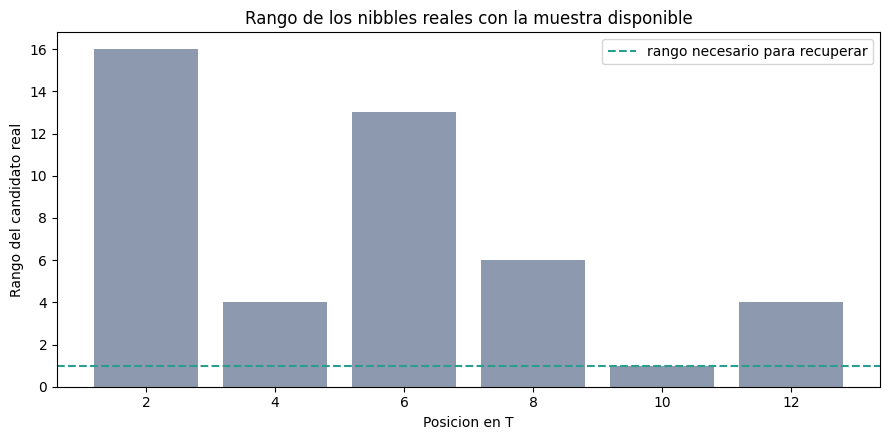

In [8]:
plt.figure(figsize=(9, 4.5))
plt.bar(result_df["posicion"].astype(str), result_df["rango real"], color="#8D99AE")
plt.axhline(1, color="#2A9D8F", linestyle="--", label="rango necesario para recuperar")
plt.title("Rango de los nibbles reales con la muestra disponible")
plt.xlabel("Posicion en T")
plt.ylabel("Rango del candidato real")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Conclusion

La trayectoria de cinco rondas tiene probabilidad $2^{-51}$, pero el key recovery depende del prefijo de cuatro rondas, cuya probabilidad es $2^{-36}$.

Con $2^{16}$ pares se esperan solamente $2^{-20}$ pares correctos. Los rankings estan dominados por ruido y no deben interpretarse como una recuperacion fiable de la subclave.

Para una recuperacion práctica serían necesarias características adicionales, estructuras de pares, técnicas de filtrado o una reducción mayor del número de rondas.